# Part II: Vegetable Image Classification with CNN and Transfer Learning

This notebook completes the Vision Task requirements:
1. Dataset understanding, visualization and preprocessing  
2. Baseline CNN from scratch  
3. Deeper CNN with Batch Normalization and Dropout  
4. Optimizer comparison: SGD vs Adam  
5. Ablation study by removing Dropout  
6. Transfer learning using MobileNetV2  
7. Evaluation using accuracy, precision, recall, F1-score, confusion matrix and sample predictions  

**Dataset:** Kaggle Vegetable Image Dataset  
**Classes:** 15 vegetable classes  


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Install and Import Libraries
Run the install cell only once if packages are missing.

In [2]:
# Uncomment and run this cell only if needed
# !pip install tensorflow numpy pandas matplotlib seaborn scikit-learn pillow

In [3]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Define Dataset Paths


In [4]:
import os
import zipfile

ZIP_PATH = "/content/drive/MyDrive/ai assignment/Vegetable_CNN_Project/archive (1).zip"
EXTRACT_DIR = "/content/vegetable_dataset"

# Create extract folder
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Unzip only if not already extracted
if not os.path.exists(os.path.join(EXTRACT_DIR, "Vegetable Images")):
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

# Dataset root folder
ROOT_DIR = os.path.join(EXTRACT_DIR, "Vegetable Images")

train_dir = os.path.join(ROOT_DIR, "train")
val_dir = os.path.join(ROOT_DIR, "validation")
test_dir = os.path.join(ROOT_DIR, "test")

# Colab output folders
OUTPUT_DIR = "/content/outputs"
GRAPH_DIR = os.path.join(OUTPUT_DIR, "graphs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
RESULT_DIR = os.path.join(OUTPUT_DIR, "results")

for folder in [OUTPUT_DIR, GRAPH_DIR, MODEL_DIR, RESULT_DIR]:
    os.makedirs(folder, exist_ok=True)

# Check paths
for path in [ROOT_DIR, train_dir, val_dir, test_dir]:
    print(path, "=>", os.path.exists(path))

Dataset extracted successfully.
/content/vegetable_dataset/Vegetable Images => True
/content/vegetable_dataset/Vegetable Images/train => True
/content/vegetable_dataset/Vegetable Images/validation => True
/content/vegetable_dataset/Vegetable Images/test => True


## 2. Dataset Understanding and Class Distribution

In [5]:
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("Class names:")
for i, name in enumerate(class_names):
    print(i, name)

def count_images_by_class(directory):
    data = []
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            count = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
            ])
            data.append({"class": cls, "count": count})
    return pd.DataFrame(data)

train_counts = count_images_by_class(train_dir)
val_counts = count_images_by_class(val_dir)
test_counts = count_images_by_class(test_dir)

distribution_df = train_counts.rename(columns={"count": "train"})
distribution_df["validation"] = val_counts["count"]
distribution_df["test"] = test_counts["count"]
distribution_df["total"] = distribution_df[["train", "validation", "test"]].sum(axis=1)

display(distribution_df)
print("Total training images:", distribution_df["train"].sum())
print("Total validation images:", distribution_df["validation"].sum())
print("Total test images:", distribution_df["test"].sum())
print("Total dataset images:", distribution_df["total"].sum())


Number of classes: 15
Class names:
0 Bean
1 Bitter_Gourd
2 Bottle_Gourd
3 Brinjal
4 Broccoli
5 Cabbage
6 Capsicum
7 Carrot
8 Cauliflower
9 Cucumber
10 Papaya
11 Potato
12 Pumpkin
13 Radish
14 Tomato


,class,train,validation,test,total
0,Bean,1000,200,200,1400
1,Bitter_Gourd,1000,200,200,1400
2,Bottle_Gourd,1000,200,200,1400
3,Brinjal,1000,200,200,1400
4,Broccoli,1000,200,200,1400
5,Cabbage,1000,200,200,1400
6,Capsicum,1000,200,200,1400
7,Carrot,1000,200,200,1400
8,Cauliflower,1000,200,200,1400
9,Cucumber,1000,200,200,1400


Total training images: 15000
Total validation images: 3000
Total test images: 3000
Total dataset images: 21000


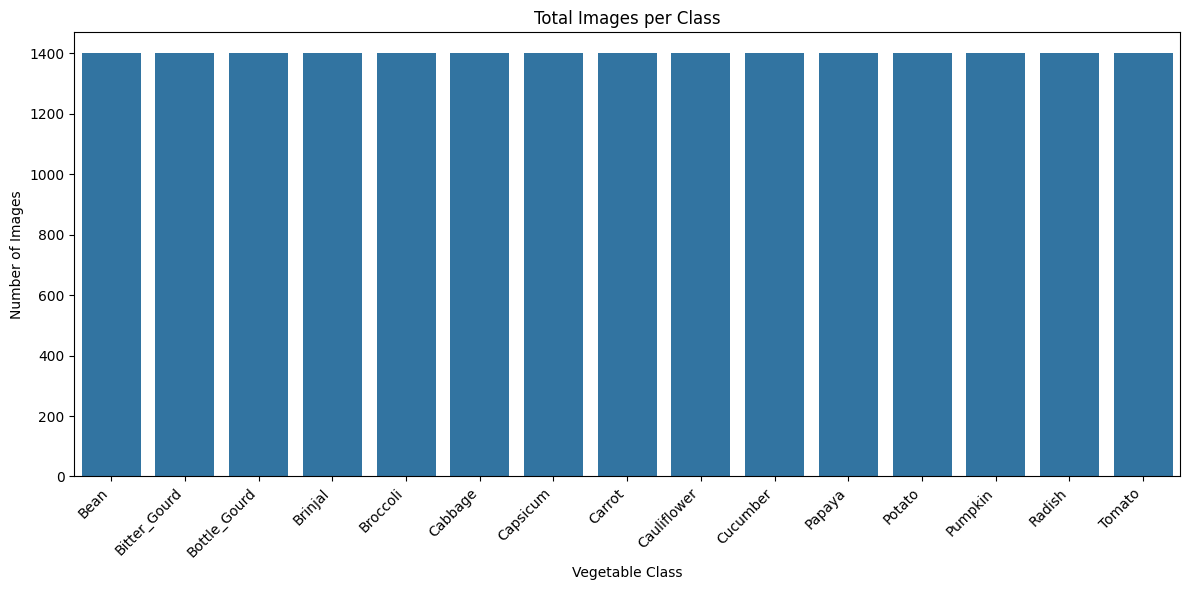

<Figure size 1400x600 with 0 Axes>

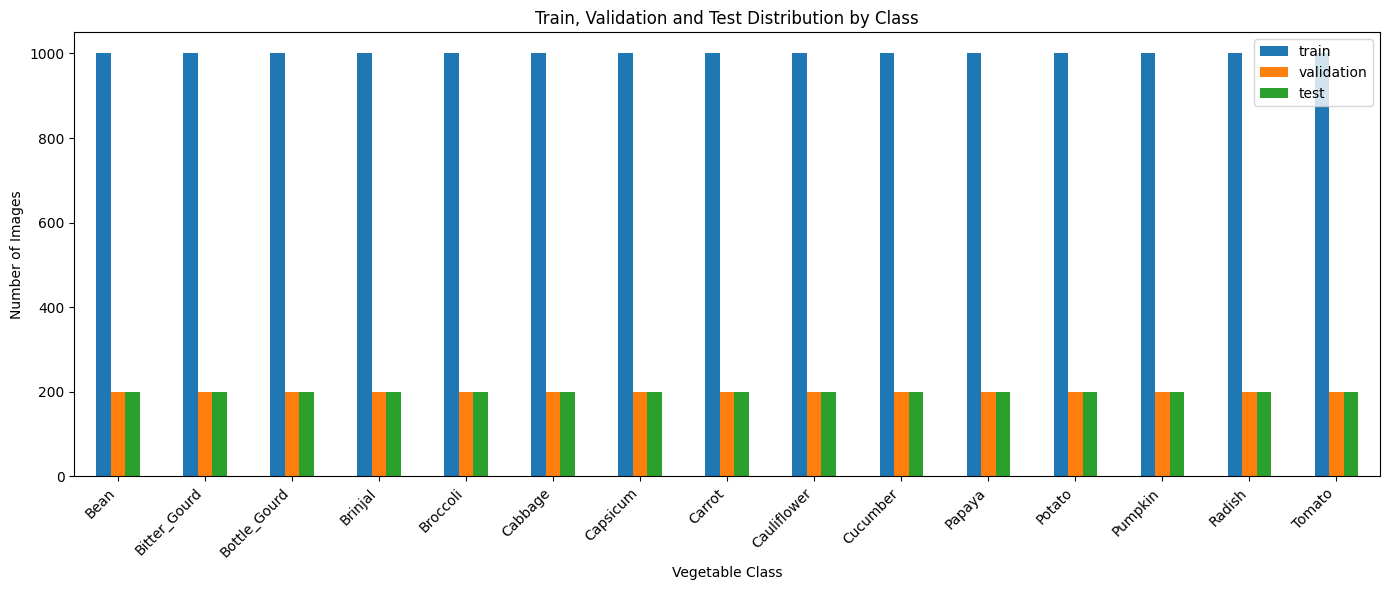

In [6]:
plt.figure(figsize=(12, 6))
sns.barplot(data=distribution_df, x="class", y="total")
plt.xticks(rotation=45, ha="right")
plt.title("Total Images per Class")
plt.xlabel("Vegetable Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "class_distribution_total.png"), dpi=300)
plt.show()

plt.figure(figsize=(14, 6))
distribution_df.set_index("class")[["train", "validation", "test"]].plot(kind="bar", figsize=(14, 6))
plt.title("Train, Validation and Test Distribution by Class")
plt.xlabel("Vegetable Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "class_distribution_split.png"), dpi=300)
plt.show()


## 3. Load Image Datasets

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds_raw.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds_raw.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
test_ds = test_ds_raw.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


Found 15000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.


## 4. Visualize Sample Images

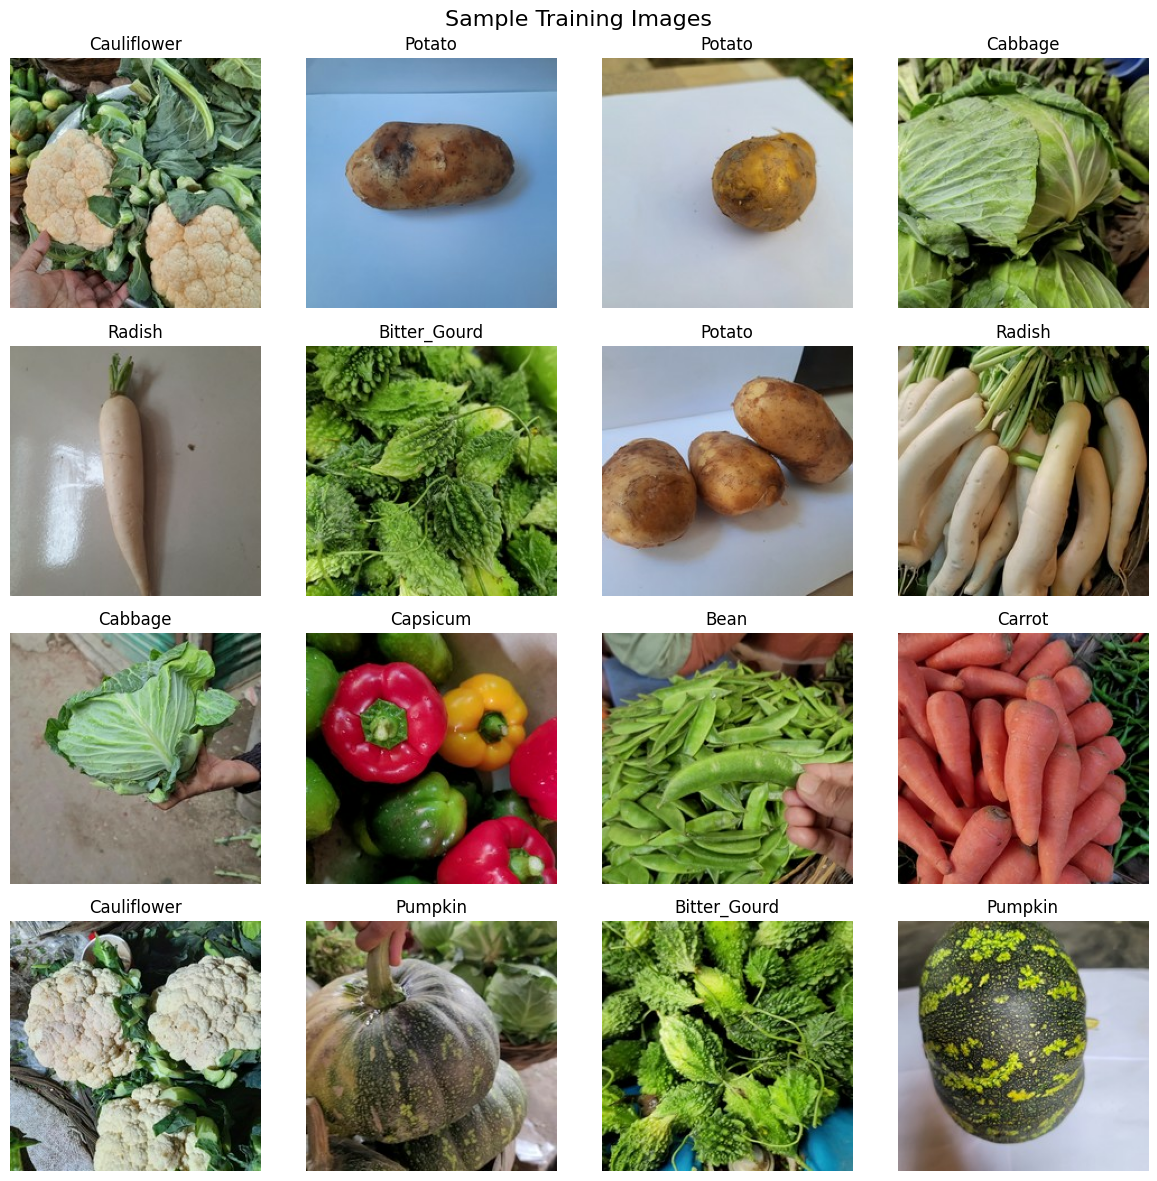

In [8]:
plt.figure(figsize=(12, 12))
for images, labels in train_ds_raw.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_index = np.argmax(labels[i].numpy())
        plt.title(class_names[label_index])
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "sample_training_images.png"), dpi=300)
plt.show()


## 5. Data Augmentation
Augmentation is used only for training to improve generalization and reduce overfitting.

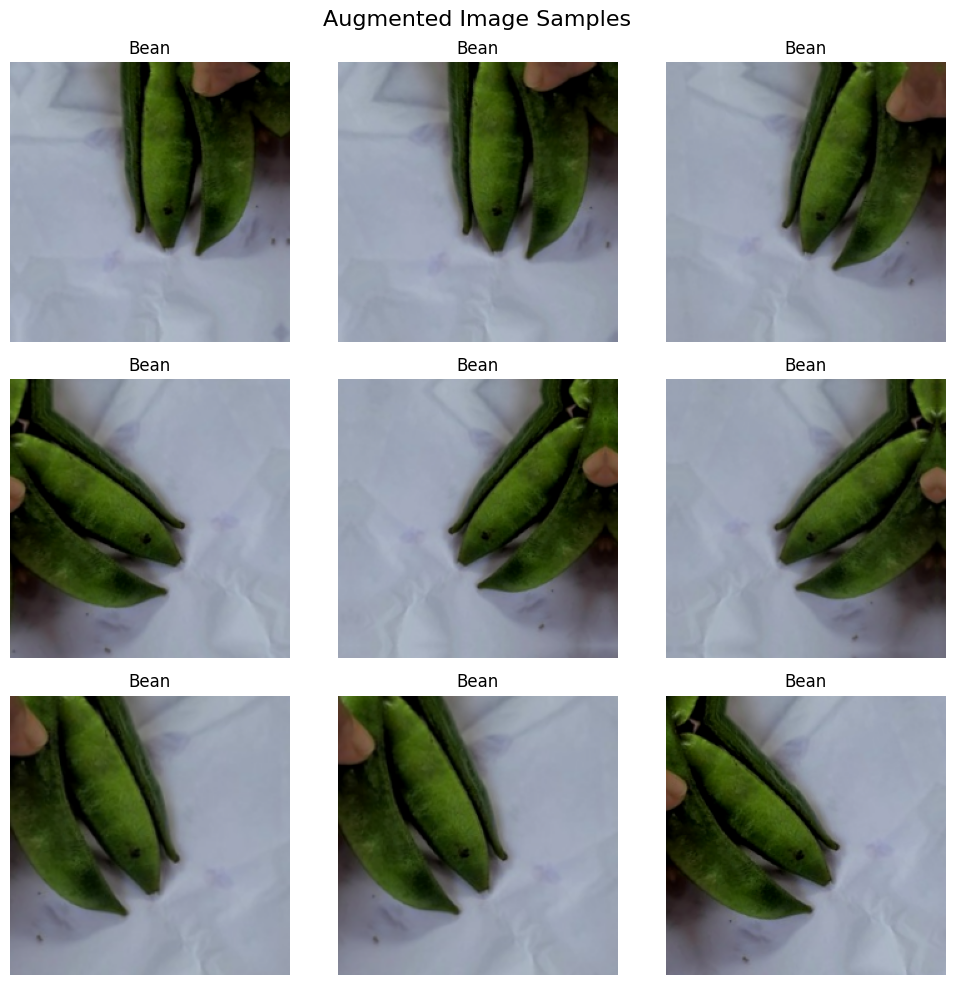

In [9]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

for images, labels in train_ds_raw.take(1):
    sample_image = images[0]
    sample_label = class_names[np.argmax(labels[0].numpy())]
    plt.figure(figsize=(10, 10))
    for i in range(9):
        augmented = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented[0].numpy().astype("uint8"))
        plt.title(sample_label)
        plt.axis("off")
    plt.suptitle("Augmented Image Samples", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, "augmented_samples.png"), dpi=300)
    plt.show()
    break


## 6. Helper Functions for Training, Plotting and Evaluation

In [10]:
def make_callbacks(model_name):
    checkpoint_path = os.path.join(MODEL_DIR, f"{model_name}.keras")
    return [
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6, verbose=1),
        ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True, verbose=1)
    ]

def plot_history(history, title, filename):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Training Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, f"{filename}_loss.png"), dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="Training Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, f"{filename}_accuracy.png"), dpi=300)
    plt.show()

def get_true_and_pred(model, dataset):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_prob.extend(probs)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

def evaluate_model(model, dataset, model_name):
    y_true, y_pred, y_prob = get_true_and_pred(model, dataset)

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    print(f"\n===== {model_name} Evaluation =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    print("\nClassification Report:")
    print(report)

    with open(os.path.join(RESULT_DIR, f"{model_name}_classification_report.txt"), "w") as f:
        f.write(report)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, f"{model_name}_confusion_matrix.png"), dpi=300)
    plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

def save_model_summary(model, model_name):
    summary_path = os.path.join(RESULT_DIR, f"{model_name}_summary.txt")
    with open(summary_path, "w", encoding="utf-8") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))
    model.summary()
    print("Model summary saved to:", summary_path)


## 7. Part A: Baseline CNN from Scratch
Required structure: three convolutional layers with pooling, three fully connected layers and an output layer.

In [11]:
def build_baseline_cnn():
    model = keras.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),

        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="baseline_cnn")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_cnn()
save_model_summary(baseline_model, "baseline_cnn")


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,825,743 (98.52 MB)

 Trainable params: 25,825,743 (98.52 MB)

 Non-trainable params: 0 (0.00 B)

Model summary saved to: /content/outputs/results/baseline_cnn_summary.txt


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3935 - loss: 1.8199
Epoch 1: val_accuracy improved from None to 0.78133, saving model to /content/outputs/models/baseline_cnn.keras

Epoch 1: finished saving model to /content/outputs/models/baseline_cnn.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - accuracy: 0.5580 - loss: 1.3198 - val_accuracy: 0.7813 - val_loss: 0.6731 - learning_rate: 0.0010
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7650 - loss: 0.7022
Epoch 2: val_accuracy improved from 0.78133 to 0.85633, saving model to /content/outputs/models/baseline_cnn.keras

Epoch 2: finished saving model to /content/outputs/models/baseline_cnn.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 79ms/step - accuracy: 0.8007 - loss: 0.6002 - val_accuracy: 0.8563 - val_loss: 0.4298 - learning_rate: 0.0010
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8679 - loss: 0.4134
Epoch 3: val_accuracy improved from 0.85633 to 0.90500, saving model t

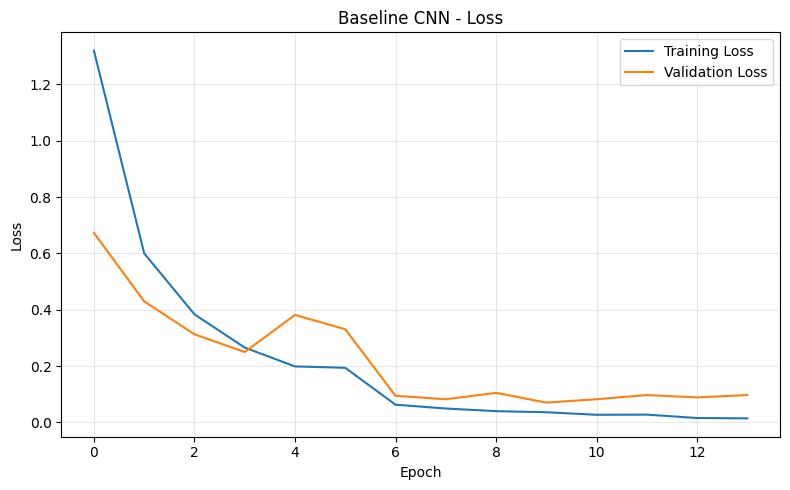

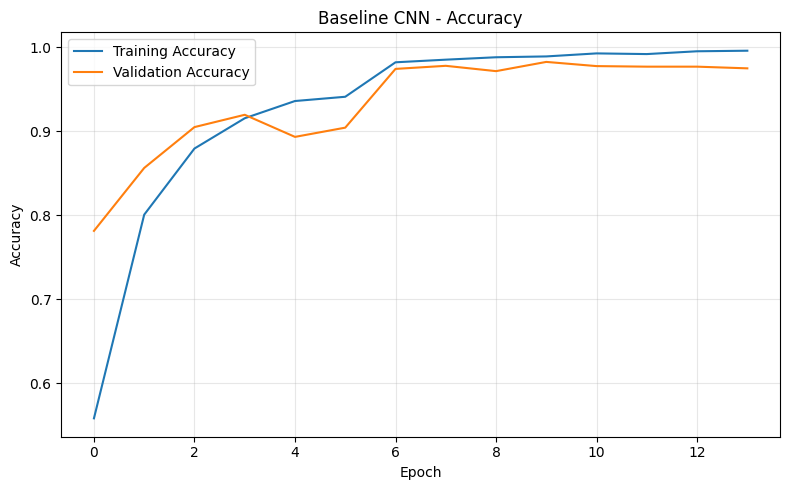


===== baseline_cnn Evaluation =====
Accuracy : 0.9817
Precision: 0.9817
Recall   : 0.9817
F1-score : 0.9817

Classification Report:
              precision    recall  f1-score   support

        Bean       0.96      0.97      0.97       200
Bitter_Gourd       0.97      0.96      0.97       200
Bottle_Gourd       1.00      0.99      0.99       200
     Brinjal       0.98      0.98      0.98       200
    Broccoli       0.98      0.95      0.97       200
     Cabbage       0.98      0.99      0.99       200
    Capsicum       0.99      1.00      0.99       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       0.98      0.97      0.98       200
    Cucumber       0.99      0.99      0.99       200
      Papaya       0.99      0.97      0.98       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       0.96      0.96      0.96       200
      Radish       0.99      0.99      0.99       200
      Tomato       0.95      0.96      0.96       200

 

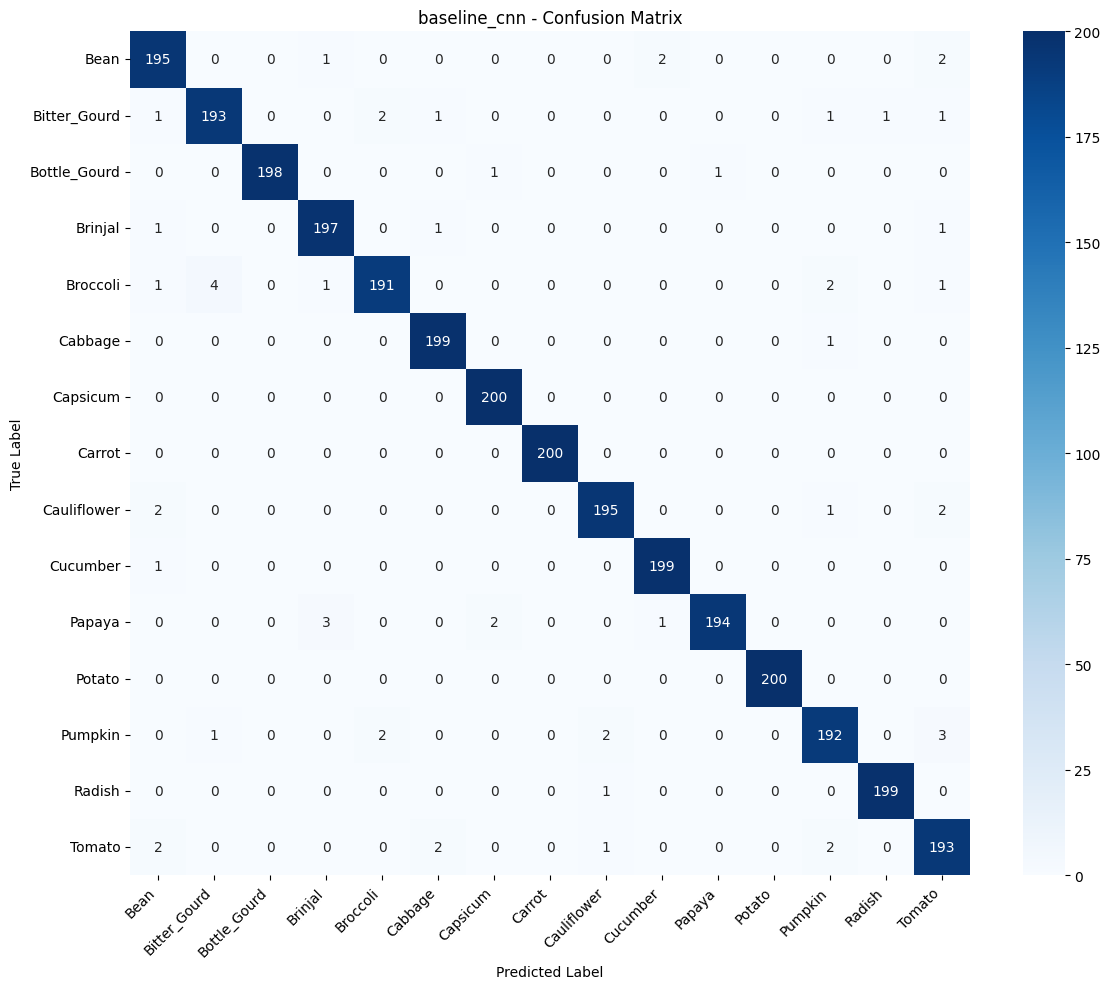

In [12]:
BASELINE_EPOCHS = 15

start_time = time.time()
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS,
    callbacks=make_callbacks("baseline_cnn"),
    verbose=1
)
baseline_training_time = time.time() - start_time

print(f"Baseline CNN training time: {baseline_training_time/60:.2f} minutes")
plot_history(baseline_history, "Baseline CNN", "baseline_cnn")
baseline_results = evaluate_model(baseline_model, test_ds, "baseline_cnn")
baseline_results["training_time_minutes"] = baseline_training_time / 60


## 8. Part A: Deeper CNN with Regularization
This model has at least double the convolution layers compared to baseline and includes Batch Normalization and Dropout.

In [13]:
def build_deeper_cnn(optimizer="adam", use_dropout=True, use_batchnorm=True):
    model = keras.Sequential(name=f"deeper_cnn_{optimizer}")
    model.add(layers.Input(shape=(224, 224, 3)))
    model.add(data_augmentation)

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizers.l2(1e-4)))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizers.l2(1e-4)))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout:
        model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizers.l2(1e-4)))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizers.l2(1e-4)))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout:
        model.add(layers.Dropout(0.30))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizers.l2(1e-4)))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizers.l2(1e-4)))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout:
        model.add(layers.Dropout(0.40))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4)))
    if use_dropout:
        model.add(layers.Dropout(0.50))
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dense(NUM_CLASSES, activation="softmax"))

    if optimizer.lower() == "sgd":
        opt = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    else:
        opt = keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

deeper_adam_model = build_deeper_cnn(optimizer="adam", use_dropout=True, use_batchnorm=True)
save_model_summary(deeper_adam_model, "deeper_cnn_adam")


Model: "deeper_cnn_adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 356,655 (1.36 MB)

 Trainable params: 355,759 (1.36 MB)

 Non-trainable params: 896 (3.50 KB)

Model summary saved to: /content/outputs/results/deeper_cnn_adam_summary.txt


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.4345 - loss: 1.7847
Epoch 1: val_accuracy improved from None to 0.28067, saving model to /content/outputs/models/deeper_cnn_adam.keras

Epoch 1: finished saving model to /content/outputs/models/deeper_cnn_adam.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 172s 345ms/step - accuracy: 0.5662 - loss: 1.3719 - val_accuracy: 0.2807 - val_loss: 4.5977 - learning_rate: 0.0010
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.7462 - loss: 0.8361
Epoch 2: val_accuracy improved from 0.28067 to 0.71133, saving model to /content/outputs/models/deeper_cnn_adam.keras

Epoch 2: finished saving model to /content/outputs/models/deeper_cnn_adam.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 158s 337ms/step - accuracy: 0.7723 - loss: 0.7775 - val_accuracy: 0.7113 - val_loss: 0.9508 - learning_rate: 0.0010
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.8207 - loss: 0.6131
Epoch 3: val_accuracy improved from 0.71133 to 0.80

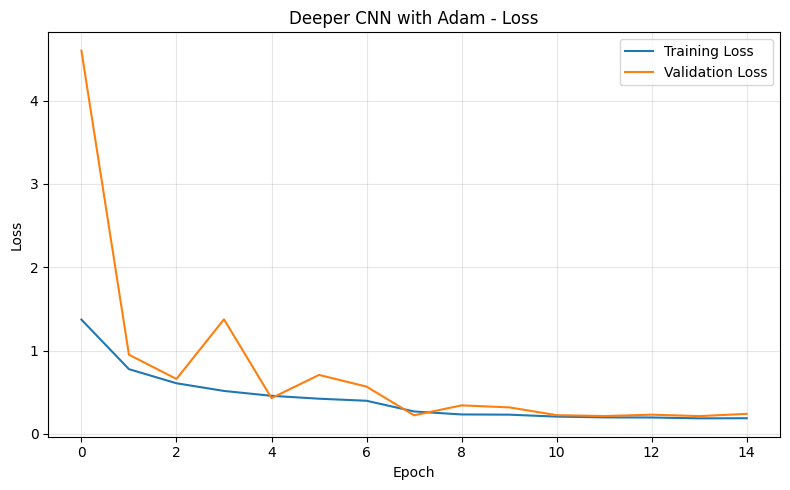

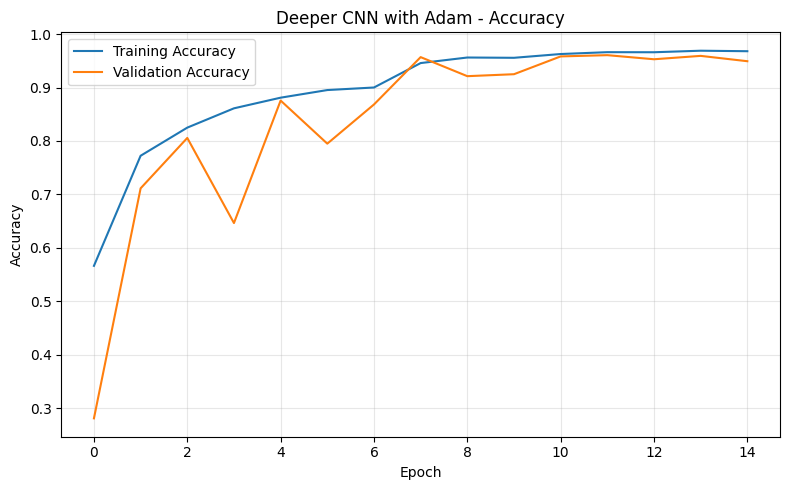


===== deeper_cnn_adam Evaluation =====
Accuracy : 0.9640
Precision: 0.9669
Recall   : 0.9640
F1-score : 0.9640

Classification Report:
              precision    recall  f1-score   support

        Bean       0.99      0.99      0.99       200
Bitter_Gourd       1.00      0.86      0.92       200
Bottle_Gourd       0.91      1.00      0.95       200
     Brinjal       0.89      0.97      0.93       200
    Broccoli       0.85      1.00      0.92       200
     Cabbage       0.98      0.94      0.96       200
    Capsicum       1.00      0.98      0.99       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       1.00      0.94      0.97       200
    Cucumber       0.98      0.98      0.98       200
      Papaya       0.98      0.86      0.92       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       0.93      0.96      0.95       200
      Radish       1.00      1.00      1.00       200
      Tomato       0.99      0.96      0.98       200

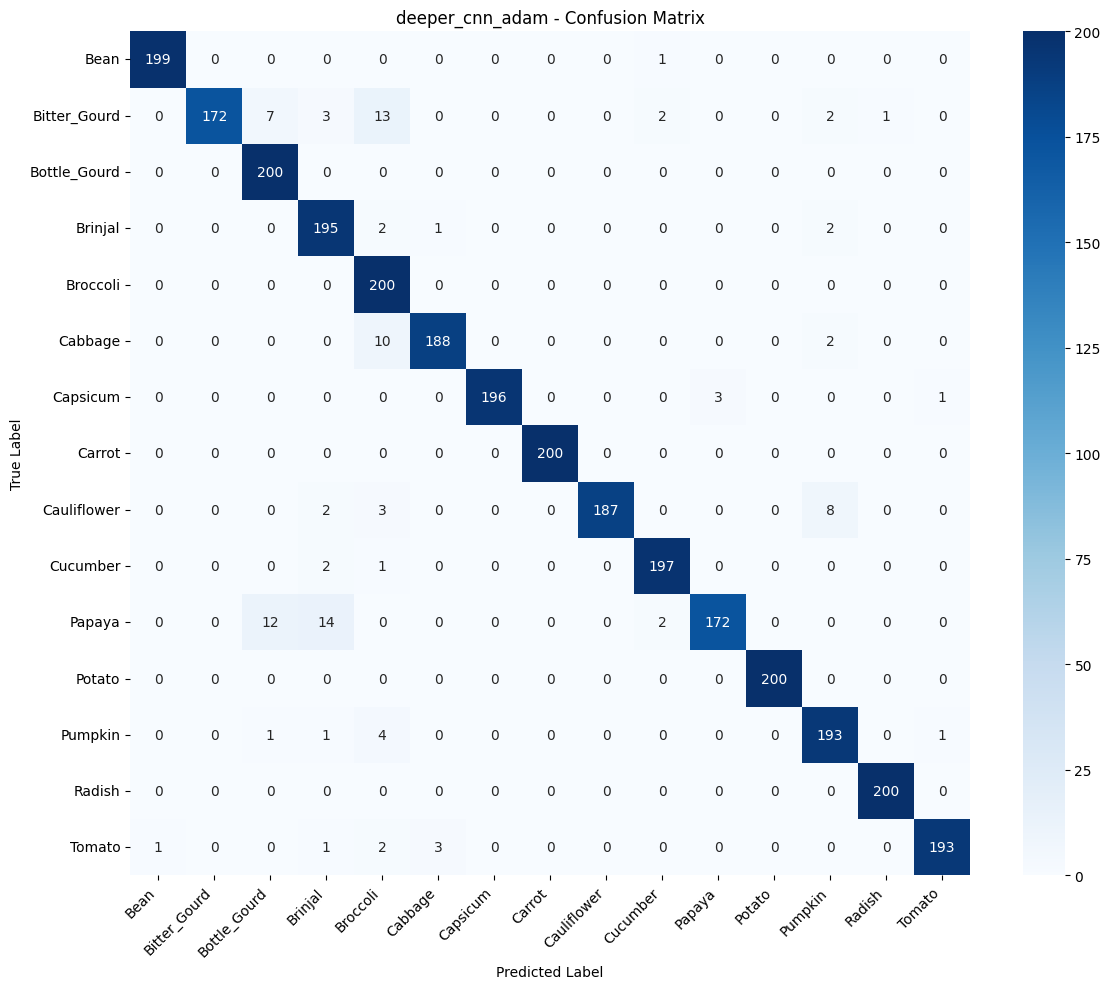

In [14]:
DEEPER_EPOCHS = 15  # For quick test, set to 3 first

start_time = time.time()
deeper_adam_history = deeper_adam_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=DEEPER_EPOCHS,
    callbacks=make_callbacks("deeper_cnn_adam"),
    verbose=1
)
deeper_adam_training_time = time.time() - start_time

print(f"Deeper CNN Adam training time: {deeper_adam_training_time/60:.2f} minutes")
plot_history(deeper_adam_history, "Deeper CNN with Adam", "deeper_cnn_adam")
deeper_adam_results = evaluate_model(deeper_adam_model, test_ds, "deeper_cnn_adam")
deeper_adam_results["training_time_minutes"] = deeper_adam_training_time / 60


## 9. Optimizer Comparison: SGD vs Adam
The same deeper architecture is trained again using SGD to compare convergence and final performance.

Model: "deeper_cnn_sgd"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 356,655 (1.36 MB)

 Trainable params: 355,759 (1.36 MB)

 Non-trainable params: 896 (3.50 KB)

Model summary saved to: /content/outputs/results/deeper_cnn_sgd_summary.txt
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.3697 - loss: 1.9474
Epoch 1: val_accuracy improved from None to 0.43300, saving model to /content/outputs/models/deeper_cnn_sgd.keras

Epoch 1: finished saving model to /content/outputs/models/deeper_cnn_sgd.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 160s 334ms/step - accuracy: 0.4933 - loss: 1.5517 - val_accuracy: 0.4330 - val_loss: 2.1313 - learning_rate: 0.0100
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.6683 - loss: 1.0472
Epoch 2: val_accuracy improved from 0.43300 to 0.63800, saving model to /content/outputs/models/deeper_cnn_sgd.keras

Epoch 2: finished saving model to /content/outputs/models/deeper_cnn_sgd.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 156s 332ms/step - accuracy: 0.6963 - loss: 0.9668 - val_accuracy: 0.6380 - val_loss: 1.1573 - learning_rate: 0.0100
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0

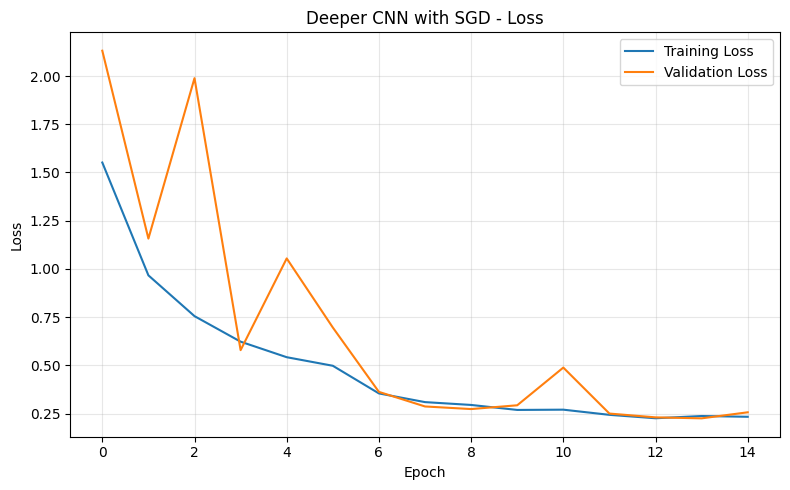

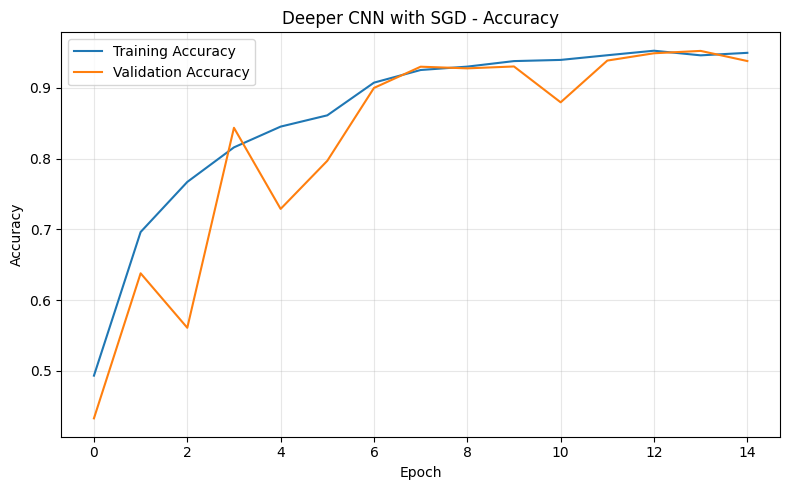


===== deeper_cnn_sgd Evaluation =====
Accuracy : 0.9523
Precision: 0.9558
Recall   : 0.9523
F1-score : 0.9526

Classification Report:
              precision    recall  f1-score   support

        Bean       0.99      0.94      0.97       200
Bitter_Gourd       0.99      0.94      0.97       200
Bottle_Gourd       0.95      0.99      0.97       200
     Brinjal       0.90      0.96      0.93       200
    Broccoli       0.81      0.98      0.89       200
     Cabbage       0.94      0.85      0.90       200
    Capsicum       0.99      0.97      0.98       200
      Carrot       0.99      1.00      1.00       200
 Cauliflower       0.99      0.92      0.95       200
    Cucumber       0.97      0.97      0.97       200
      Papaya       0.99      0.86      0.92       200
      Potato       0.99      1.00      0.99       200
     Pumpkin       0.87      0.96      0.91       200
      Radish       0.99      0.99      0.99       200
      Tomato       0.97      0.92      0.94       200


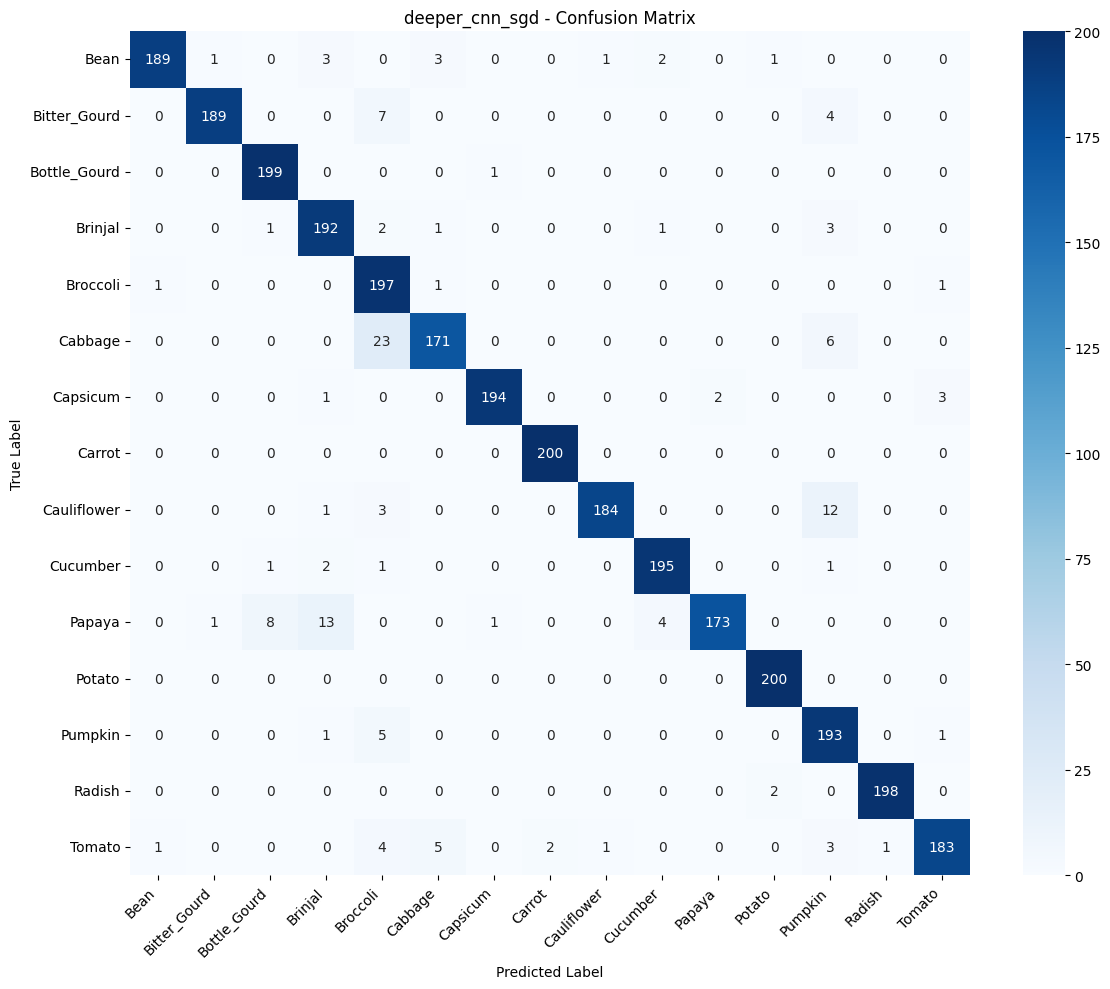

In [15]:
deeper_sgd_model = build_deeper_cnn(optimizer="sgd", use_dropout=True, use_batchnorm=True)
save_model_summary(deeper_sgd_model, "deeper_cnn_sgd")

start_time = time.time()
deeper_sgd_history = deeper_sgd_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=DEEPER_EPOCHS,
    callbacks=make_callbacks("deeper_cnn_sgd"),
    verbose=1
)
deeper_sgd_training_time = time.time() - start_time

print(f"Deeper CNN SGD training time: {deeper_sgd_training_time/60:.2f} minutes")
plot_history(deeper_sgd_history, "Deeper CNN with SGD", "deeper_cnn_sgd")
deeper_sgd_results = evaluate_model(deeper_sgd_model, test_ds, "deeper_cnn_sgd")
deeper_sgd_results["training_time_minutes"] = deeper_sgd_training_time / 60


## 10. Ablation Study: Removing Dropout
This experiment removes Dropout while keeping the deeper architecture mostly the same.

Model: "deeper_cnn_adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             

 Total params: 356,655 (1.36 MB)

 Trainable params: 355,759 (1.36 MB)

 Non-trainable params: 896 (3.50 KB)

Model summary saved to: /content/outputs/results/ablation_no_dropout_summary.txt
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.5653 - loss: 1.4105
Epoch 1: val_accuracy improved from None to 0.38500, saving model to /content/outputs/models/ablation_no_dropout.keras

Epoch 1: finished saving model to /content/outputs/models/ablation_no_dropout.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 146s 297ms/step - accuracy: 0.6791 - loss: 1.0477 - val_accuracy: 0.3850 - val_loss: 2.9540 - learning_rate: 0.0010
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.8229 - loss: 0.6000
Epoch 2: val_accuracy improved from 0.38500 to 0.82300, saving model to /content/outputs/models/ablation_no_dropout.keras

Epoch 2: finished saving model to /content/outputs/models/ablation_no_dropout.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 305ms/step - accuracy: 0.8449 - loss: 0.5408 - val_accuracy: 0.8230 - val_loss: 0.6038 - learning_rate: 0.0010
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s

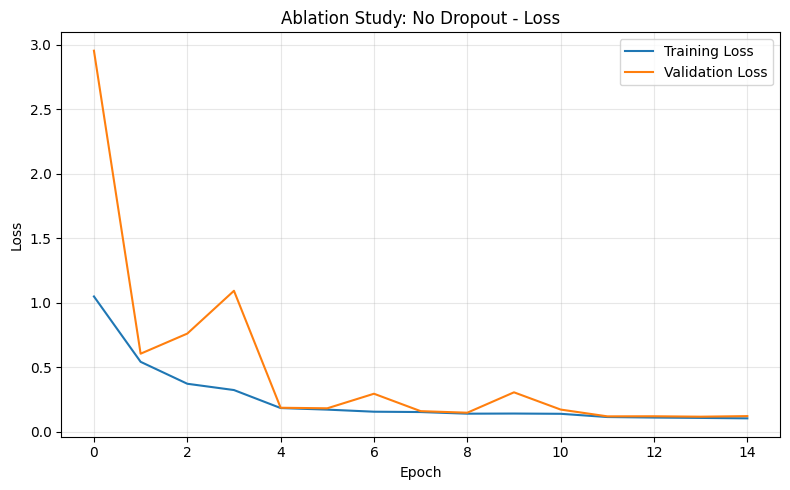

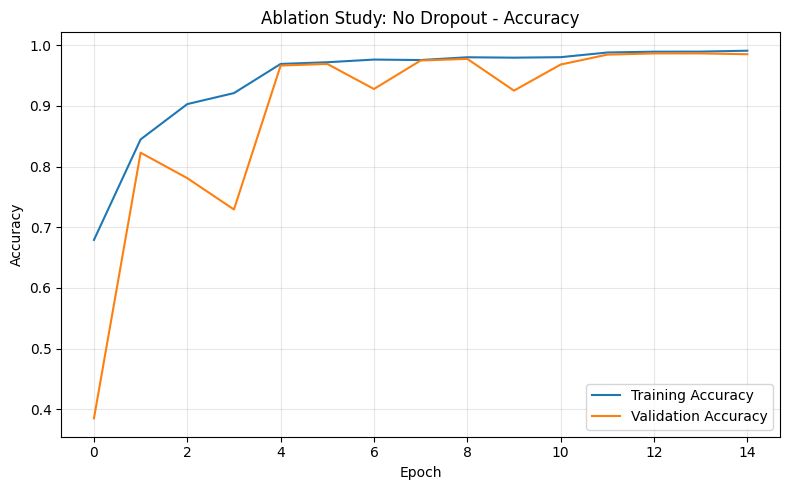


===== ablation_no_dropout Evaluation =====
Accuracy : 0.9843
Precision: 0.9848
Recall   : 0.9843
F1-score : 0.9843

Classification Report:
              precision    recall  f1-score   support

        Bean       0.99      0.99      0.99       200
Bitter_Gourd       0.99      0.96      0.98       200
Bottle_Gourd       0.97      1.00      0.98       200
     Brinjal       0.94      0.98      0.96       200
    Broccoli       0.97      1.00      0.99       200
     Cabbage       0.98      0.98      0.98       200
    Capsicum       1.00      0.99      0.99       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       1.00      0.97      0.99       200
    Cucumber       0.99      0.98      0.99       200
      Papaya       0.99      0.93      0.96       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       0.95      1.00      0.97       200
      Radish       1.00      1.00      1.00       200
      Tomato       0.99      0.97      0.98      

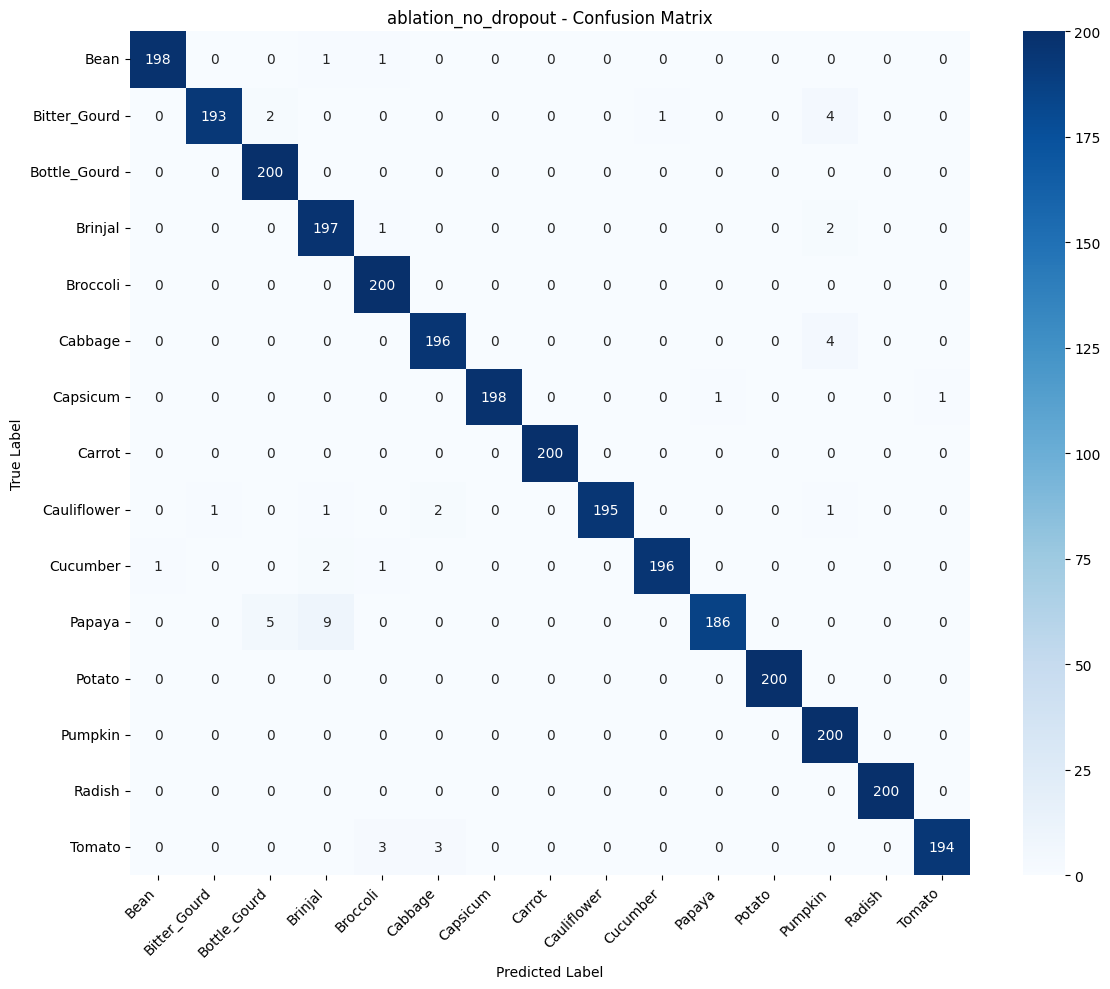

In [16]:
ablation_model = build_deeper_cnn(optimizer="adam", use_dropout=False, use_batchnorm=True)
save_model_summary(ablation_model, "ablation_no_dropout")

start_time = time.time()
ablation_history = ablation_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=DEEPER_EPOCHS,
    callbacks=make_callbacks("ablation_no_dropout"),
    verbose=1
)
ablation_training_time = time.time() - start_time

print(f"Ablation no-dropout training time: {ablation_training_time/60:.2f} minutes")
plot_history(ablation_history, "Ablation Study: No Dropout", "ablation_no_dropout")
ablation_results = evaluate_model(ablation_model, test_ds, "ablation_no_dropout")
ablation_results["training_time_minutes"] = ablation_training_time / 60


## 11. Part B: Transfer Learning using MobileNetV2
MobileNetV2 is selected because it is lightweight, fast and pre-trained on ImageNet.

In [17]:
transfer_train_ds = train_ds_raw.prefetch(AUTOTUNE)
transfer_val_ds = val_ds_raw.prefetch(AUTOTUNE)
transfer_test_ds = test_ds_raw.prefetch(AUTOTUNE)

def build_transfer_model(train_base=False):
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = train_base

    inputs = keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

transfer_model, base_model = build_transfer_model(train_base=False)
save_model_summary(transfer_model, "mobilenetv2_feature_extraction")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Model summary saved to: /content/outputs/results/mobilenetv2_feature_extraction_summary.txt


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7328 - loss: 0.9078
Epoch 1: val_accuracy improved from None to 0.99233, saving model to /content/outputs/models/mobilenetv2_feature_extraction.keras

Epoch 1: finished saving model to /content/outputs/models/mobilenetv2_feature_extraction.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 83ms/step - accuracy: 0.8828 - loss: 0.4048 - val_accuracy: 0.9923 - val_loss: 0.0302 - learning_rate: 5.0000e-04
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9717 - loss: 0.0971
Epoch 2: val_accuracy improved from 0.99233 to 0.99733, saving model to /content/outputs/models/mobilenetv2_feature_extraction.keras

Epoch 2: finished saving model to /content/outputs/models/mobilenetv2_feature_extraction.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - accuracy: 0.9744 - loss: 0.0840 - val_accuracy: 0.9973 - val_loss: 0.0142 - learning_rate: 5.0000e-04
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9809 - los

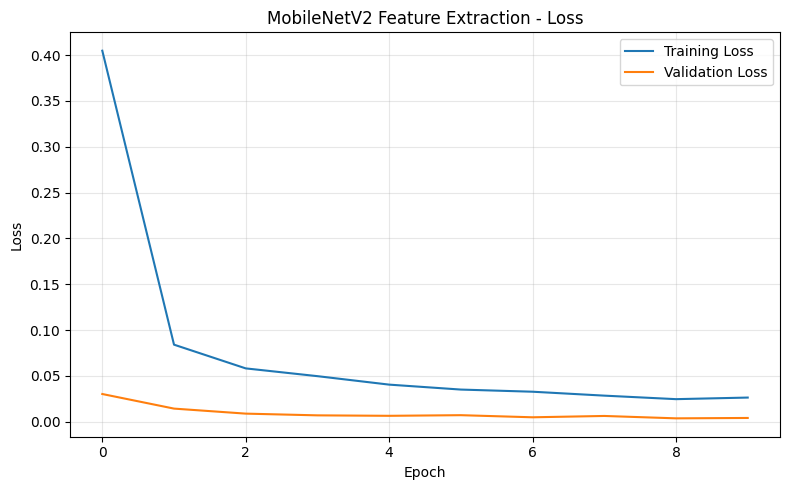

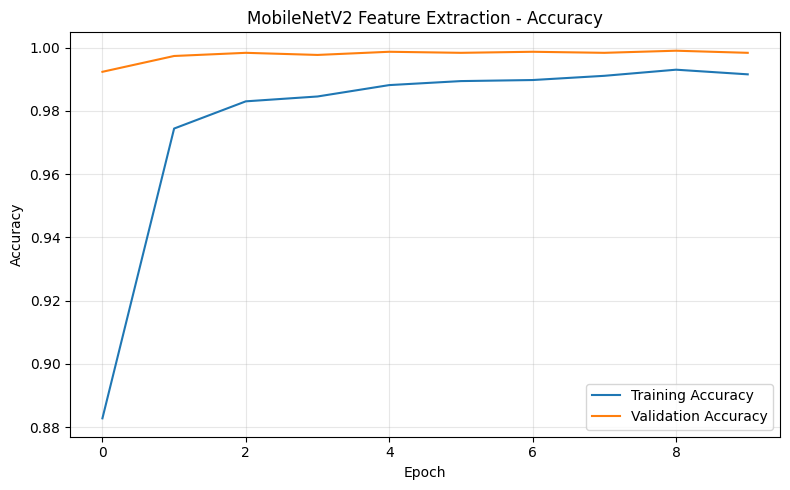


===== mobilenetv2_feature_extraction Evaluation =====
Accuracy : 0.9977
Precision: 0.9977
Recall   : 0.9977
F1-score : 0.9977

Classification Report:
              precision    recall  f1-score   support

        Bean       0.99      1.00      1.00       200
Bitter_Gourd       1.00      0.99      0.99       200
Bottle_Gourd       1.00      1.00      1.00       200
     Brinjal       1.00      1.00      1.00       200
    Broccoli       0.99      0.99      0.99       200
     Cabbage       1.00      1.00      1.00       200
    Capsicum       1.00      1.00      1.00       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       1.00      0.99      1.00       200
    Cucumber       0.99      0.99      0.99       200
      Papaya       1.00      1.00      1.00       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       1.00      1.00      1.00       200
      Radish       1.00      0.99      1.00       200
      Tomato       0.99      0.99     

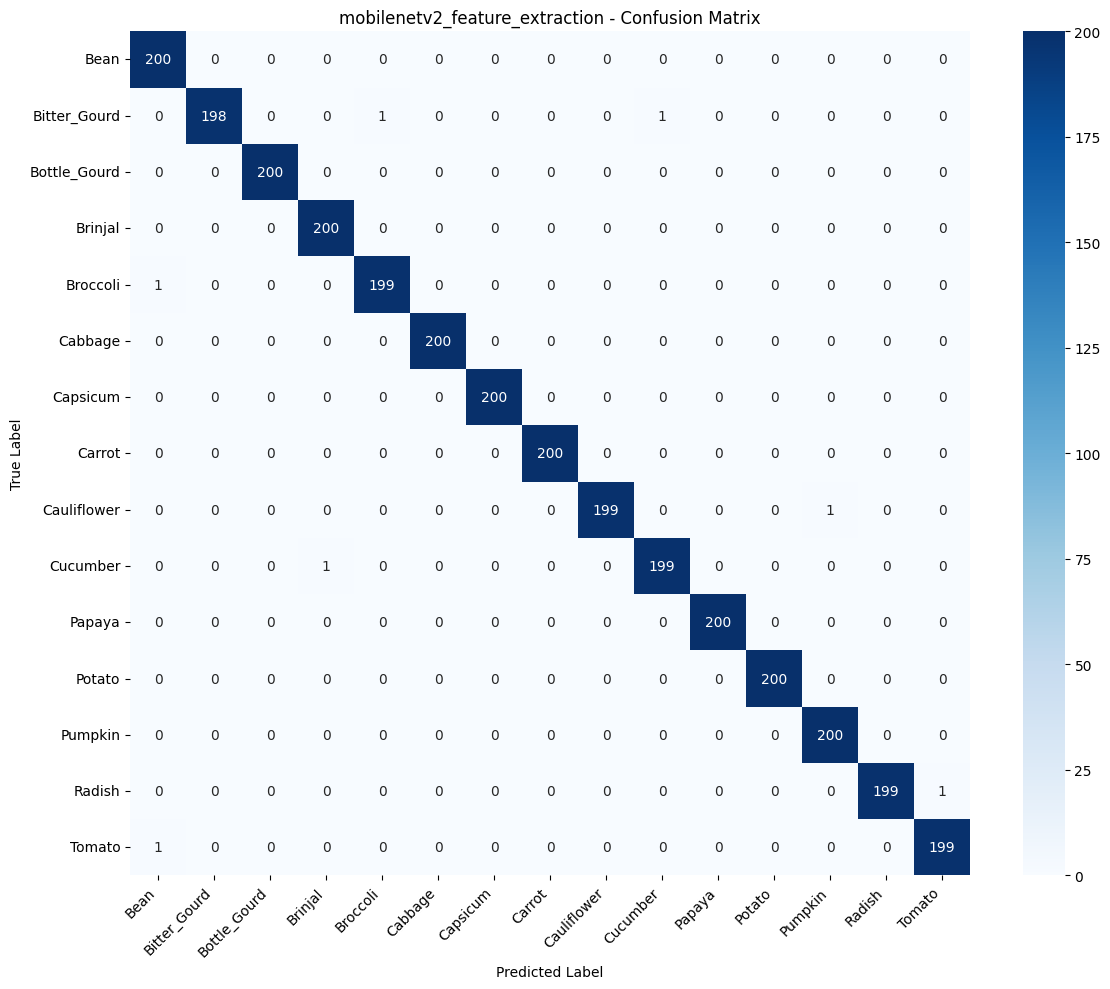

In [18]:
TRANSFER_EPOCHS = 10  # For quick test, set to 3 first

start_time = time.time()
transfer_history = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=TRANSFER_EPOCHS,
    callbacks=make_callbacks("mobilenetv2_feature_extraction"),
    verbose=1
)
transfer_training_time = time.time() - start_time

print(f"MobileNetV2 feature extraction training time: {transfer_training_time/60:.2f} minutes")
plot_history(transfer_history, "MobileNetV2 Feature Extraction", "mobilenetv2_feature_extraction")
transfer_results = evaluate_model(transfer_model, transfer_test_ds, "mobilenetv2_feature_extraction")
transfer_results["training_time_minutes"] = transfer_training_time / 60


## 12. Fine-Tuning MobileNetV2
Fine-tuning unfreezes the last layers of the pre-trained convolutional base using a low learning rate.

In [19]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

trainable_count = sum([layer.trainable for layer in base_model.layers])
print(trainable_count, "trainable layers in MobileNetV2 base")
save_model_summary(transfer_model, "mobilenetv2_finetuned")


30 trainable layers in MobileNetV2 base


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 1,692,303 (6.46 MB)

 Non-trainable params: 731,584 (2.79 MB)

Model summary saved to: /content/outputs/results/mobilenetv2_finetuned_summary.txt


Epoch 1/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9020 - loss: 0.3437
Epoch 1: val_accuracy improved from None to 0.99700, saving model to /content/outputs/models/mobilenetv2_finetuned.keras

Epoch 1: finished saving model to /content/outputs/models/mobilenetv2_finetuned.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 104ms/step - accuracy: 0.9339 - loss: 0.2192 - val_accuracy: 0.9970 - val_loss: 0.0087 - learning_rate: 1.0000e-05
Epoch 2/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9698 - loss: 0.0876
Epoch 2: val_accuracy improved from 0.99700 to 0.99867, saving model to /content/outputs/models/mobilenetv2_finetuned.keras

Epoch 2: finished saving model to /content/outputs/models/mobilenetv2_finetuned.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 109ms/step - accuracy: 0.9743 - loss: 0.0769 - val_accuracy: 0.9987 - val_loss: 0.0065 - learning_rate: 1.0000e-05
Epoch 3/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9837 - loss: 0.0559
Epoch 3: val_accuracy impro

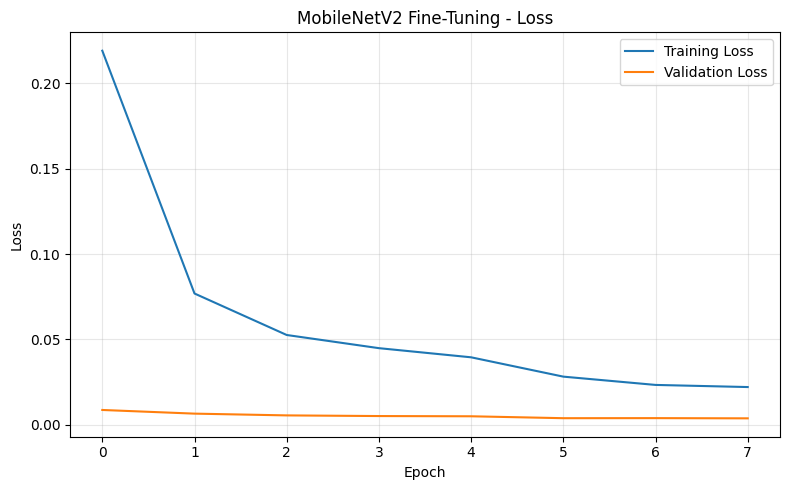

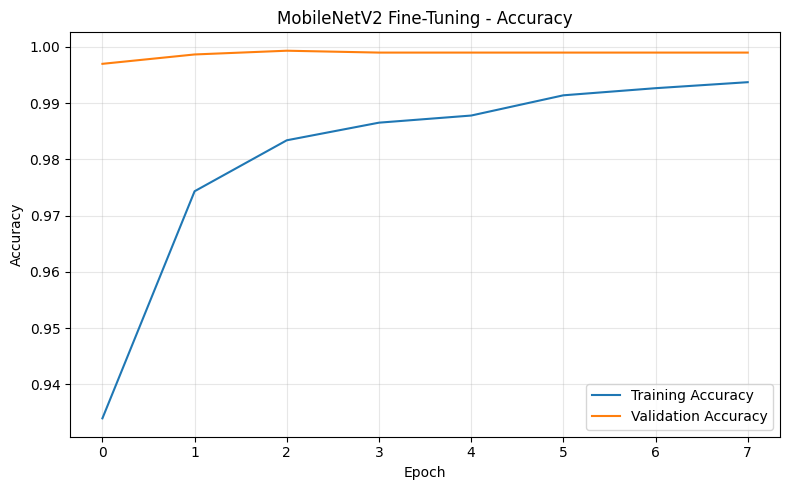


===== mobilenetv2_finetuned Evaluation =====
Accuracy : 0.9987
Precision: 0.9987
Recall   : 0.9987
F1-score : 0.9987

Classification Report:
              precision    recall  f1-score   support

        Bean       1.00      1.00      1.00       200
Bitter_Gourd       1.00      0.99      0.99       200
Bottle_Gourd       1.00      1.00      1.00       200
     Brinjal       1.00      1.00      1.00       200
    Broccoli       1.00      1.00      1.00       200
     Cabbage       1.00      1.00      1.00       200
    Capsicum       1.00      1.00      1.00       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       1.00      1.00      1.00       200
    Cucumber       1.00      1.00      1.00       200
      Papaya       1.00      1.00      1.00       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       1.00      0.99      1.00       200
      Radish       1.00      1.00      1.00       200
      Tomato       1.00      0.99      1.00    

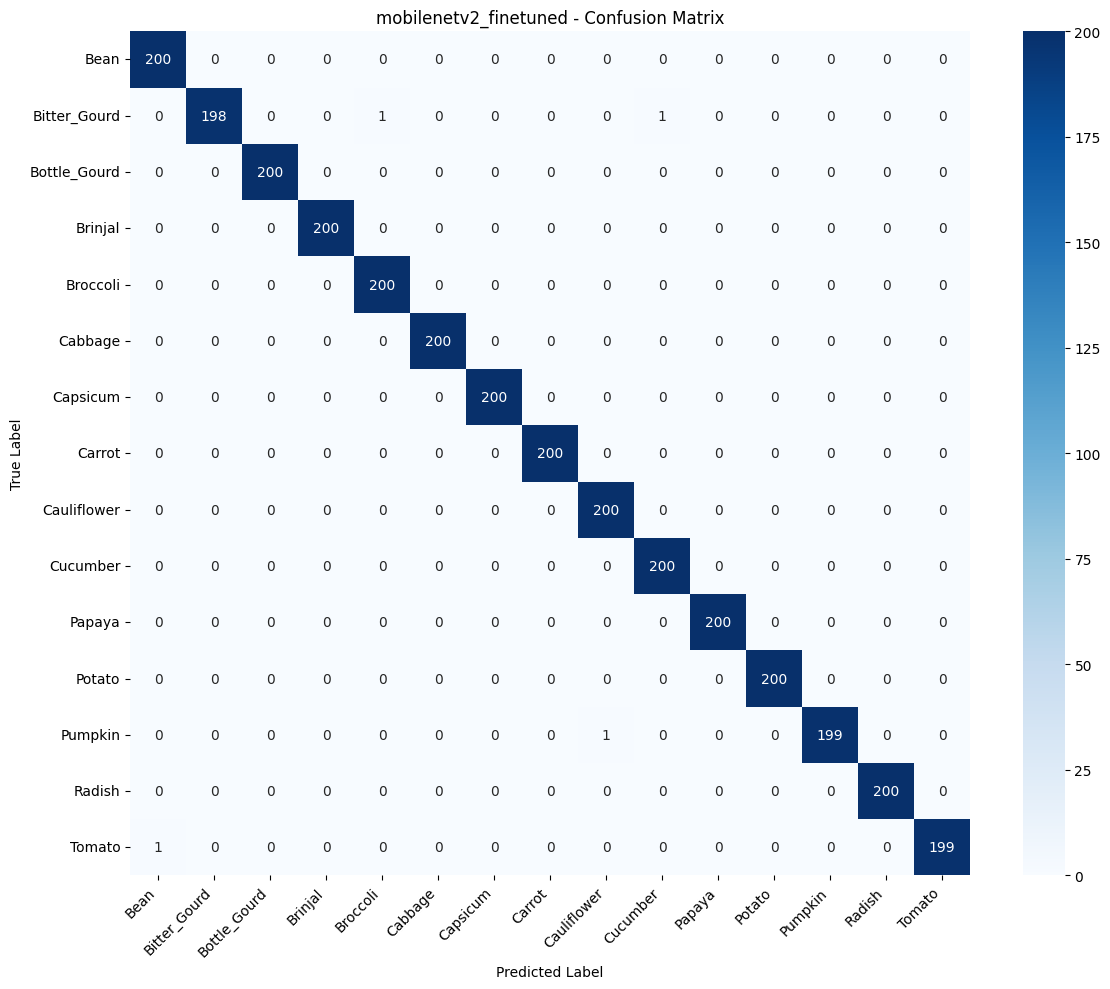

In [20]:
FINE_TUNE_EPOCHS = 8  # For quick test, set to 2 first

start_time = time.time()
finetune_history = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=make_callbacks("mobilenetv2_finetuned"),
    verbose=1
)
finetune_training_time = time.time() - start_time

print(f"MobileNetV2 fine-tuning time: {finetune_training_time/60:.2f} minutes")
plot_history(finetune_history, "MobileNetV2 Fine-Tuning", "mobilenetv2_finetuned")
finetune_results = evaluate_model(transfer_model, transfer_test_ds, "mobilenetv2_finetuned")
finetune_results["training_time_minutes"] = (transfer_training_time + finetune_training_time) / 60


## 13. Final Comparative Analysis Table

,model,accuracy,precision,recall,f1_score,training_time_minutes
0,baseline_cnn,0.981667,0.981738,0.981667,0.981660,8.775494
1,deeper_cnn_adam,0.964000,0.966937,0.964000,0.964048,39.784410
2,deeper_cnn_sgd,0.952333,0.955830,0.952333,0.952631,39.091368
3,ablation_no_dropout,0.984333,0.984828,0.984333,0.984347,35.123572
4,mobilenetv2_feature_extraction,0.997667,0.997677,0.997667,0.997667,6.372274
5,mobilenetv2_finetuned,0.998667,0.998673,0.998667,0.998666,12.857631


Saved final results to: /content/outputs/results/final_model_comparison.csv


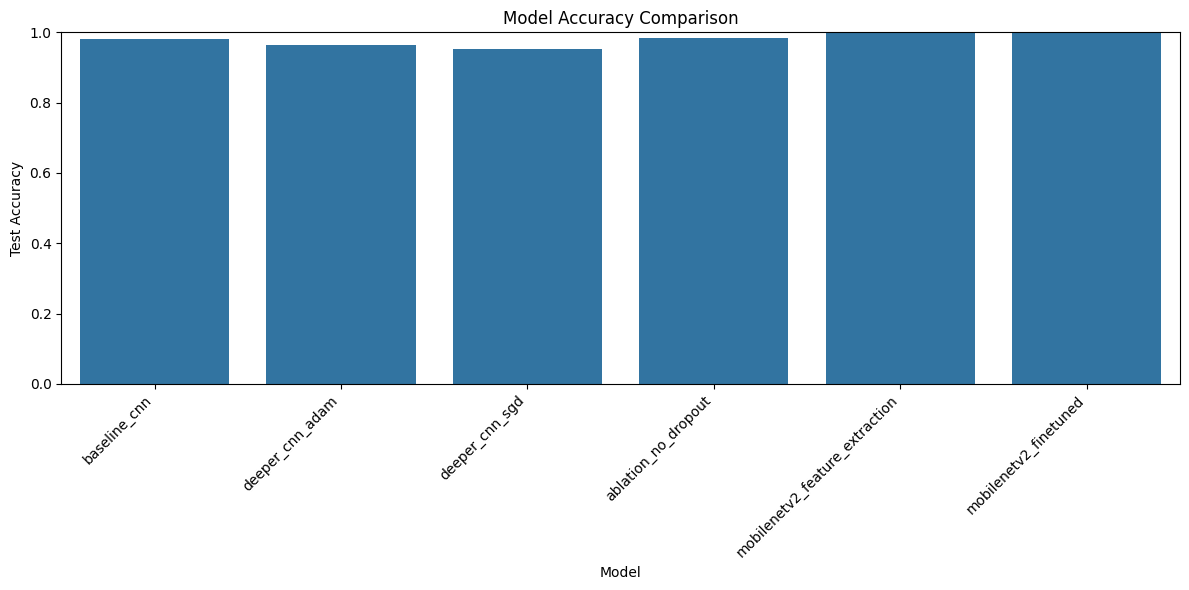

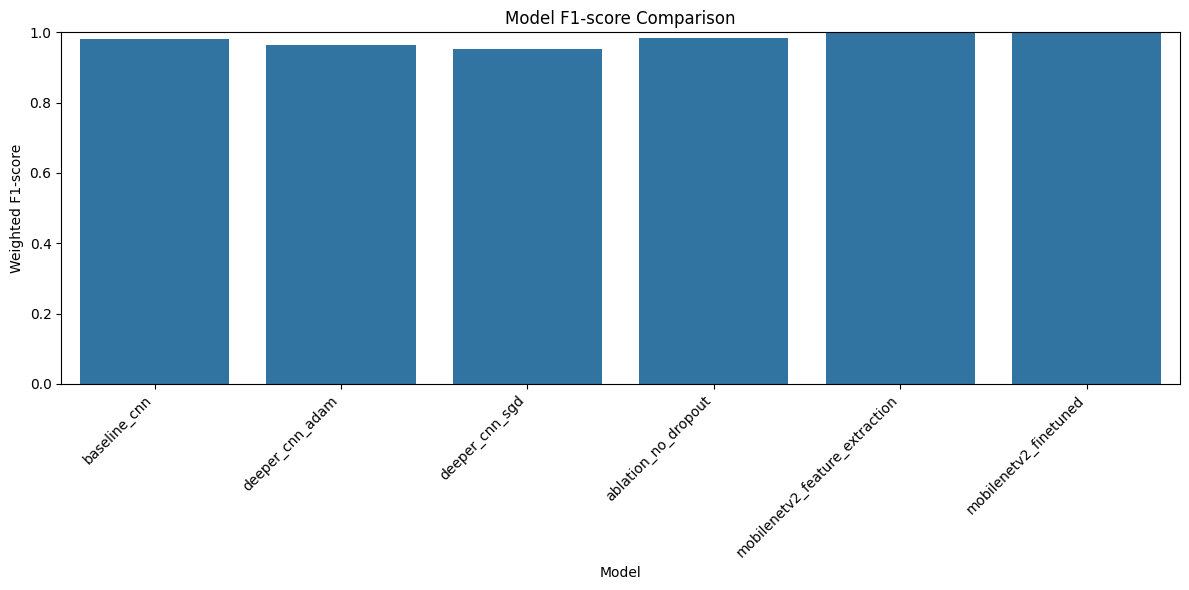

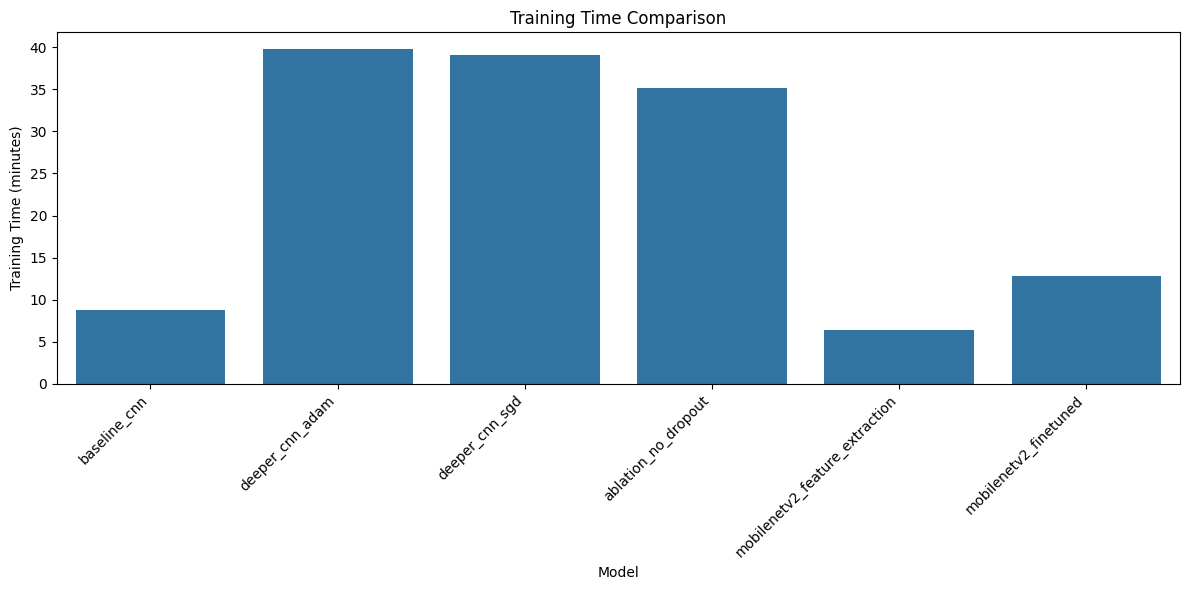

In [21]:
results_list = [
    baseline_results,
    deeper_adam_results,
    deeper_sgd_results,
    ablation_results,
    transfer_results,
    finetune_results
]

results_df = pd.DataFrame(results_list)
display(results_df)

results_csv_path = os.path.join(RESULT_DIR, "final_model_comparison.csv")
results_df.to_csv(results_csv_path, index=False)
print("Saved final results to:", results_csv_path)

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="model", y="accuracy")
plt.xticks(rotation=45, ha="right")
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "model_accuracy_comparison.png"), dpi=300)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="model", y="f1_score")
plt.xticks(rotation=45, ha="right")
plt.title("Model F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("Weighted F1-score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "model_f1_comparison.png"), dpi=300)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="model", y="training_time_minutes")
plt.xticks(rotation=45, ha="right")
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (minutes)")
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "training_time_comparison.png"), dpi=300)
plt.show()


## 14. Inference on Sample Test Images

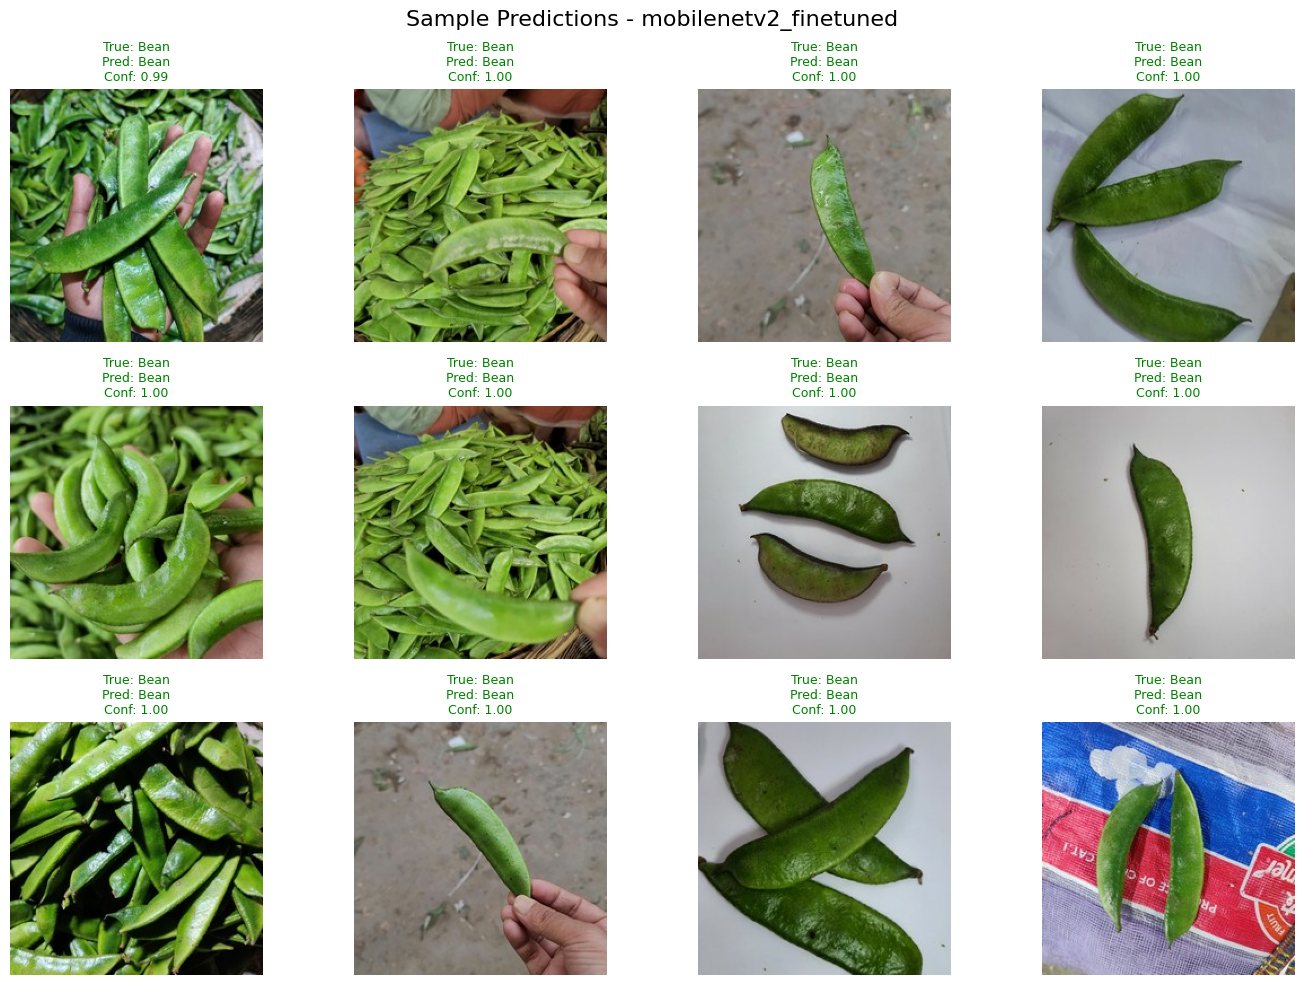

In [22]:
def show_sample_predictions(model, dataset, model_name, raw=False, num_images=12):
    plt.figure(figsize=(14, 10))

    for images, labels in dataset.take(1):
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)
        true_labels = np.argmax(labels.numpy(), axis=1)

        for i in range(min(num_images, len(images))):
            ax = plt.subplot(3, 4, i + 1)
            img = images[i].numpy()
            if not raw:
                img = np.clip(img, 0, 1)
            else:
                img = img.astype("uint8")
            plt.imshow(img)

            pred_name = class_names[preds[i]]
            true_name = class_names[true_labels[i]]
            confidence = np.max(probs[i])

            color = "green" if pred_name == true_name else "red"
            plt.title(f"True: {true_name}\nPred: {pred_name}\nConf: {confidence:.2f}", color=color, fontsize=9)
            plt.axis("off")

    plt.suptitle(f"Sample Predictions - {model_name}", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, f"{model_name}_sample_predictions.png"), dpi=300)
    plt.show()

show_sample_predictions(transfer_model, transfer_test_ds, "mobilenetv2_finetuned", raw=True)


## 15. Save Final Best Model

In [23]:
final_model_path = os.path.join(MODEL_DIR, "best_vegetable_classifier_mobilenetv2.keras")
transfer_model.save(final_model_path)
print("Final model saved to:", final_model_path)

class_names_path = os.path.join(RESULT_DIR, "class_names.txt")
with open(class_names_path, "w") as f:
    for cls in class_names:
        f.write(cls + "\n")
print("Class names saved to:", class_names_path)


Final model saved to: /content/outputs/models/best_vegetable_classifier_mobilenetv2.keras
Class names saved to: /content/outputs/results/class_names.txt
